## COMPARISON BETWEEN KMEANS AND DBSCAN

In this script we will see how the K-means and DBSCAN algorithm behave on different dataset and how tuning the parameters for fitting the data the best possible.

#### DBSCAN
<img src="dbscan.gif"/>

### Comparisong with Kmeans on some assumptions
<img src="dbscan.png">

[0 0 2 ... 1 1 1]
Estimated number of clusters: 3
Estimated number of noise points: 9
Silhouette Coefficient for K-means: 0.73
Silhouette Coefficient for DBSCAN: 0.71


Text(0.5, 1.0, 'Incorrect Number of Blobs')

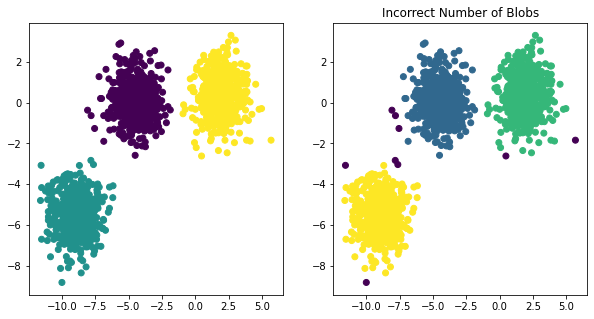

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

plt.figure(figsize=(10, 5))

n_samples = 1500
random_state = 170
X, y = make_blobs(n_samples=n_samples, random_state=random_state)

km = KMeans(n_clusters=3, random_state=random_state).fit(X)
k_pred = km.labels_

db = DBSCAN(eps=0.9, min_samples=10).fit(X)
labels =  db.labels_
# label=-1 means the point is an outlier. Rest of the values represent the label/cluster number starting from 0
print(labels)# Creating a numpy array with all values set to false by default

core_samples_mask = np.zeros_like(labels, dtype=bool)# Setting core and border points (all points that are not -1) to True

core_samples_mask[db.core_sample_indices_] = True# Finding the number of clusters in labels (ignoring noise if present)

n_clusters_ = len(set(db.labels_)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)# Printing the number of clusters and number of noise points (outliers)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)# Evaluating the quality of clusters

s_km = silhouette_score(X, k_pred)
s_db = silhouette_score(X, labels)
print(f"Silhouette Coefficient for K-means: {s_km:.2f}")
print(f"Silhouette Coefficient for DBSCAN: {s_db:.2f}")


plt.subplot(121)
plt.scatter(X[:, 0], X[:, 1], c=k_pred)

plt.subplot(122)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
plt.scatter(X[:, 0], X[:, 1],c=labels)
plt.title("Incorrect Number of Blobs")

[0 0 1 ... 2 2 2]
Estimated number of clusters: 3
Estimated number of noise points: 13
Silhouette Coefficient for K-means: 0.51
Silhouette Coefficient for DBSCAN: 0.47


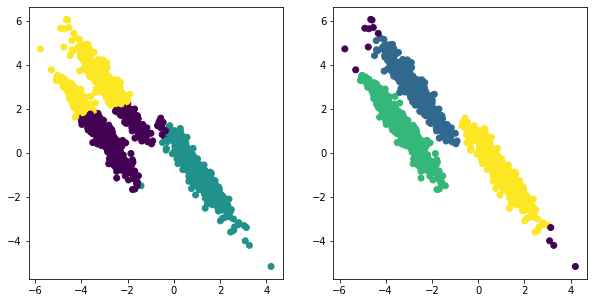

In [2]:
# Anisotropicly distributed data
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X, transformation)
y_pred_aniso = KMeans(n_clusters=3, random_state=random_state).fit_predict(X_aniso)

db = DBSCAN(eps=0.35, min_samples=5).fit(X_aniso)
labels =  db.labels_
# label=-1 means the point is an outlier. Rest of the values represent the label/cluster number starting from 0
print(labels)# Creating a numpy array with all values set to false by default

core_samples_mask = np.zeros_like(labels, dtype=bool)# Setting core and border points (all points that are not -1) to True

core_samples_mask[db.core_sample_indices_] = True# Finding the number of clusters in labels (ignoring noise if present)

n_clusters_ = len(set(db.labels_)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)# Printing the number of clusters and number of noise points (outliers)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)# Evaluating the quality of clusters

s_km = silhouette_score(X_aniso, y_pred_aniso)
s_db = silhouette_score(X_aniso, labels)
print(f"Silhouette Coefficient for K-means: {s_km:.2f}")
print(f"Silhouette Coefficient for DBSCAN: {s_db:.2f}")

plt.figure(figsize=(10, 5))
plt.title("Anisotropicly Distributed Blobs")

plt.subplot(121)
plt.scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred_aniso)

plt.subplot(122)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
plt.scatter(X_aniso[:, 0], X_aniso[:, 1],c=labels)

plt.show()

### Homework

Replicate the experiment with the difference-variance dataset and the filtered dataset and look for the attributes for the clustering algorithms that fit the best the distribution of the samples

[-1 -1 -1 ...  0 33  0]
Estimated number of clusters: 51
Estimated number of noise points: 582
Silhouette Coefficient for K-means: 0.62
Silhouette Coefficient for DBSCAN: -0.28


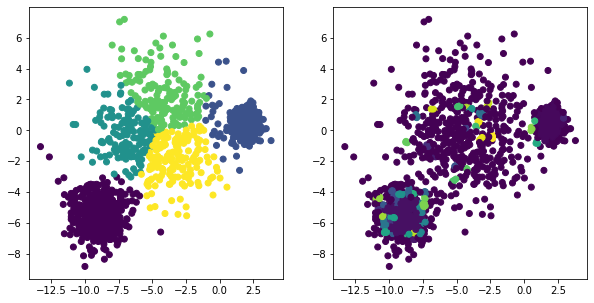

In [20]:
# Different variance
X_varied, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state)

y_pred_varied = KMeans(n_clusters=5, random_state=random_state).fit_predict(X_varied)

db = DBSCAN(eps=0.15, min_samples=3).fit(X_varied)
labels =  db.labels_
# label=-1 means the point is an outlier. Rest of the values represent the label/cluster number starting from 0
print(labels)# Creating a numpy array with all values set to false by default

core_samples_mask = np.zeros_like(labels, dtype=bool)# Setting core and border points (all points that are not -1) to True

core_samples_mask[db.core_sample_indices_] = True# Finding the number of clusters in labels (ignoring noise if present)

n_clusters_ = len(set(db.labels_)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)# Printing the number of clusters and number of noise points (outliers)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)# Evaluating the quality of clusters

s_km = silhouette_score(X_varied, y_pred_varied)
s_db = silhouette_score(X_varied, labels)
print(f"Silhouette Coefficient for K-means: {s_km:.2f}")
print(f"Silhouette Coefficient for DBSCAN: {s_db:.2f}")

plt.figure(figsize=(10, 5))
plt.title("Anisotropicly Distributed Blobs")

plt.subplot(121)
plt.scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred_varied)

plt.subplot(122)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
plt.scatter(X_varied[:, 0], X_varied[:, 1],c=labels)

plt.show()

[-1  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0
  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0 -1  0  0  0  1  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0 -1  0  0  0 -1  0  0  0  0  0  0  0 -1  0  0  0  0  0
  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0 -1  0  0  0 -1 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
 -1  0 -1  0 -1  0  0  0  0  0 -1  1  0 -1  0  0 -1  0  0  0  0  0  0  0
  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0

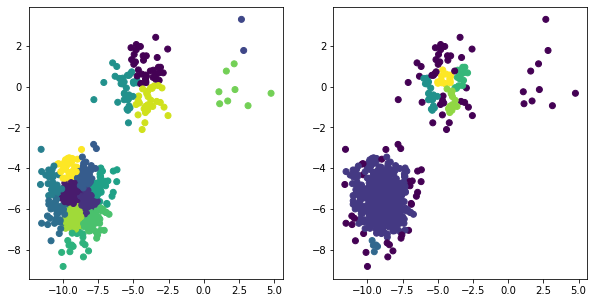

In [21]:
# Unevenly sized blobs
X, y = make_blobs(n_samples=n_samples, random_state=random_state)
X_filtered = np.vstack((X[y == 0][:500], X[y == 1][:100], X[y == 2][:10]))

y_pred_varied = KMeans(n_clusters=15, random_state=random_state).fit_predict(X_filtered)

db = DBSCAN(eps=0.35, min_samples=5).fit(X_filtered)
labels =  db.labels_
# label=-1 means the point is an outlier. Rest of the values represent the label/cluster number starting from 0
print(labels)# Creating a numpy array with all values set to false by default

core_samples_mask = np.zeros_like(labels, dtype=bool)# Setting core and border points (all points that are not -1) to True

core_samples_mask[db.core_sample_indices_] = True# Finding the number of clusters in labels (ignoring noise if present)

n_clusters_ = len(set(db.labels_)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)# Printing the number of clusters and number of noise points (outliers)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)# Evaluating the quality of clusters

s_km = silhouette_score(X_filtered, y_pred_varied)
s_db = silhouette_score(X_filtered, labels)
print(f"Silhouette Coefficient for K-means: {s_km:.2f}")
print(f"Silhouette Coefficient for DBSCAN: {s_db:.2f}")

plt.figure(figsize=(10, 5))
plt.title("Anisotropicly Distributed Blobs")

plt.subplot(121)
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred_varied)

plt.subplot(122)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
plt.scatter(X_filtered[:, 0], X_filtered[:, 1],c=labels)

plt.show()